# Seismic Sensor Analysis Cross Correlation Tutorial

### Simon Ramirez

This Jupyter Notebook details how to use the align.py file from the GitHub Repository https://github.com/Ramirezs873/seismic-sensor-analysis.

ObsPy is needed for this process. https://github.com/obspy/obspy.

## 0. Imports

In [28]:
import align
from obspy import UTCDateTime as UTC
from obspy import read
from collections import defaultdict
import matplotlib.pyplot as plt


## 1. Gather Seismic Data
The function seismic_data() is used to simply gather waveform data from seismic sensors through an FDSN client. For some networks, a username and password is required. If a username and password is not needed, then leave those parameters as default. 

For this tutorial, the times listed are for the September 10th, 2022, PNG Earthquake (Magnitude 7.6).

Time is in UTC.

In [2]:
client1 = "IRIS"
network1 = "IU"
station1 = "CASY"
location1 = "00"
channel1 = "BH?"
t_start = UTC(2022, 9, 10, 23, 45, 0)
t_end = UTC(2022, 9, 11, 1, 0, 0)
user1 = None
password1 = None

In [3]:
data = align.seismic_data(client1, 
                          network1, 
                          station1, 
                          location1, 
                          channel1, 
                          t_start, 
                          t_end,
                          user1,
                          password1)

File not found. Downloading data


This saves the waveform data as an mseed titled "station_data_{network}_{No_of_Stations}_{time}.mseed" and writes it to a dictionary. Upon running the code again, the function checks first to see if there is a previous file.

## 2. Visualising the Data

plot_streams() is used to easily visualise the waveform data. It uses waveform data from a dictionary. Plotting colour can be changed (default 'black').

For this tutorial plot_streams() will not be used further but feel free to try it after each step as a visual aid.

In [4]:
wave_dict = data
color = "blue"

Plotting IU.CASY.00


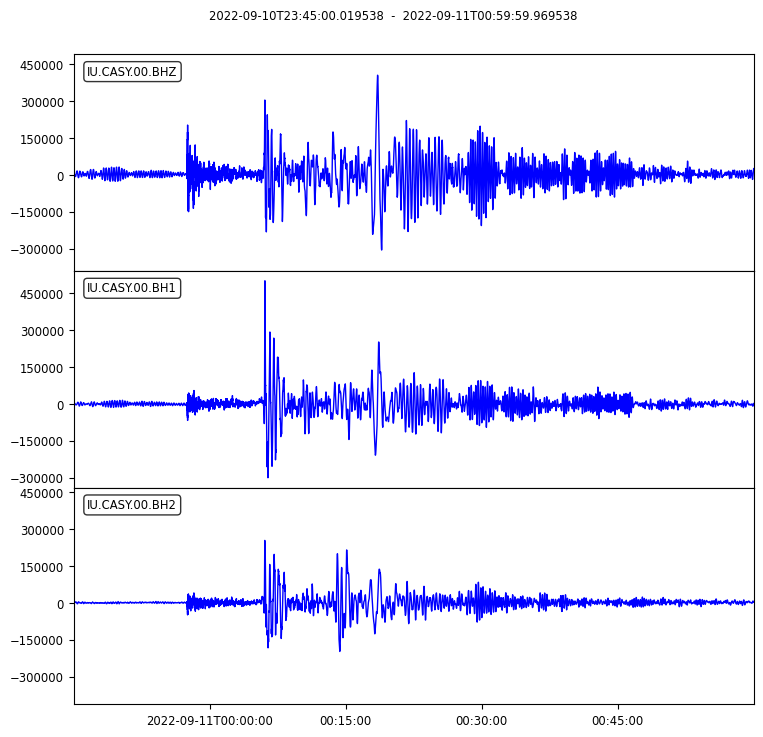

In [5]:
align.plot_streams(wave_dict, color)

## 3. Selecting a Time Window

The function select_time() is used to trim the waveform data to a desired length. 

The trimmed time focuses on the surface wave of the PNG earthquake.

wave_dict is a dictionary.

t_start is in UTC.

duration is in seconds.

In [6]:
wave_dict = data
t_start = UTC(2022, 9, 11, 0, 6,25)
duration = 40

In [7]:
trim = align.select_time(wave_dict, t_start, duration)

## 4. Window Functions

apply_window allows for a window function to be applied to the waveform data to assist with the removal of unwanted artifacts at the ends of a time span from trimming or otherwise.

wave_dict is a dictionary.

type can be any listed from the obspy.core.trace.Trace.taper function.

max_percentage is a decimal percentage (default = None).

max_length is in seconds (default = 1).

side can be "left", "right", or "both".

In [8]:
wave_dict = trim
type = 'hann'
max_percentage = None
max_length = 1
side = 'both'

In [9]:
win = align.apply_window(wave_dict, type, max_percentage, max_length, side)

## 5. Filtering

apply_filter() removes unwanted frequencies from the waveform data.

wave_dict is a dictionary.

filter_type can be 'bandpass', 'bandstop', 'lowpass', or 'highpass'.
    if bandspass or bandstop is chosen then a minimum and maximum frequency (Hz)needs to be chosen.
    if lowpass or highpass is chosen then a cutoff frequency (Hz) needs to be chosen.

corners is an int.

zerophase applies a zero-phase filter (default = False). 

In [10]:
wave_dict = win
filter_type = 'bandpass'
freqmin = 0.005
freqmax = 8
freq = None
corners = 4
zerophase = False

In [11]:
CASY_filt = align.apply_filter(wave_dict, 
                          filter_type, 
                          freqmin, 
                          freqmax, 
                          freq, 
                          corners, 
                          zerophase)

## 5. Cross Correlation

For cross correlation, the previous steps need to be conducted for another station. 

For the Casey-Wilkins Adaptable Array, a username and password is required and thus the code will not be setup here as it will leak currently protected data. Instead the process was completed externally and a file will be read instead with the necessary waveform data. Please download CWA.72_example.mseed for this section.

In [12]:
filename = "CWA.72_example.mseed"
CWA72_data = read(filename)
CWA72_dict = defaultdict(list) 
for tr in CWA72_data:
    station = (f"{tr.stats.network}."
               f"{tr.stats.station}."
               f"{tr.stats.location}")
    CWA72_dict[station].append(tr)
CWA_win = align.apply_window(CWA72_dict, type='hann', max_percentage = None, max_length=1, side='both')
CWA_filt = align.apply_filter(CWA_win, filter_type='bandpass', freqmin=0.005, freqmax=8, freq=None, corners=4, zerophase=False)

For cross correlation, the CWA.72 will be cross referenced to CASY. 

cc_correction() cross correlates target waveform data to a reference and corrects the signal to horizontal alignment. The target waveform goes through a complex transformation for accurate horizontal rotation.

ref_dict is a reference dictionary.

target_dict is a target dictionary.

NS_channel is the north-south sensor channels.

EW_channel is the east-west sensor channels.

In [13]:
ref_dict = CASY_filt
target_dict = CWA_filt
NS_channel = ['BH1', 'HHN']
EW_channel = ['BH2', 'HHE']

For plotting, 

underlying_plot has the options 'reference' and 'original' to choose what is plotted alongside the target signals. 'original' plots the original target (CWA.72) waveform with the aligned target (CWA.72) waveform. 'reference' plots the reference (CASY) waveform with the aligned target (CWA.72) waveform.

col_n is an int. The number of columns in the plot. Change for presentation reasons or when working with a large number of stations.

For saving,
png_title is for the title (default = 'default).
save_png saves the image as a png (True/False).

Processing reference station: IU.CASY.00...
Processing Z9.CWA72....
Rotation required for best correlation at Z9.CWA72.: 35.20°


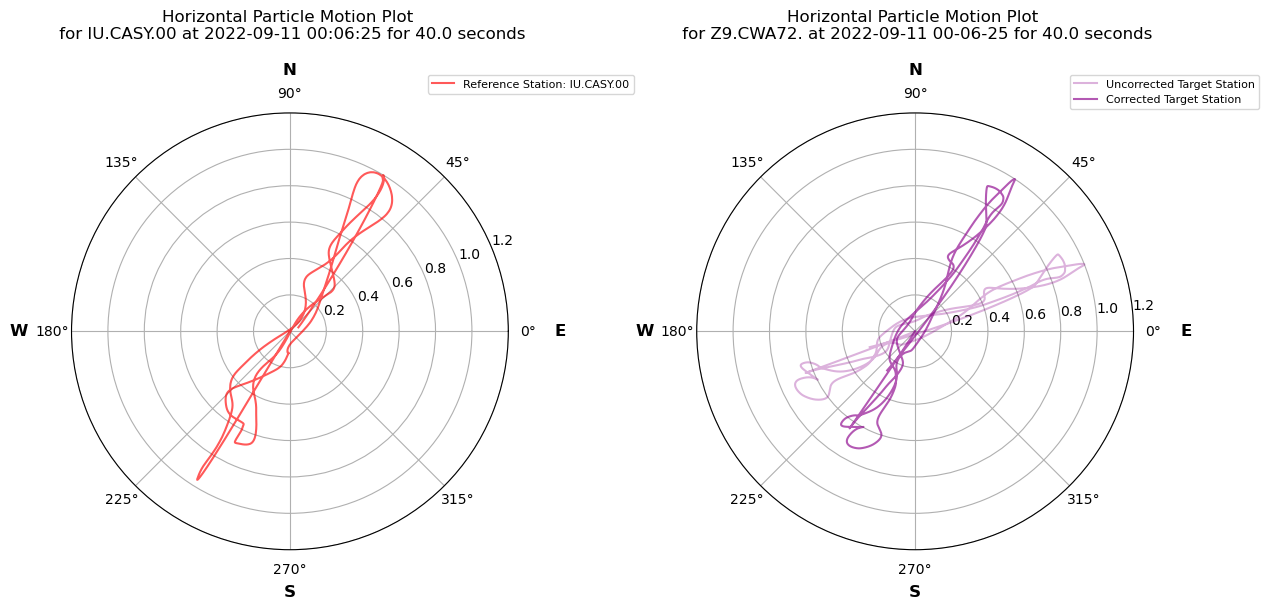

In [14]:
align.cc_correction(ref_dict, 
                    target_dict, 
                    NS_channel, 
                    EW_channel, 
                    col_n = 4, 
                    underlying_plot='original', 
                    png_title='Example_Original_CC',
                    save_png=True)

Processing reference station: IU.CASY.00...
Processing Z9.CWA72....
Rotation required for best correlation at Z9.CWA72.: 35.20°


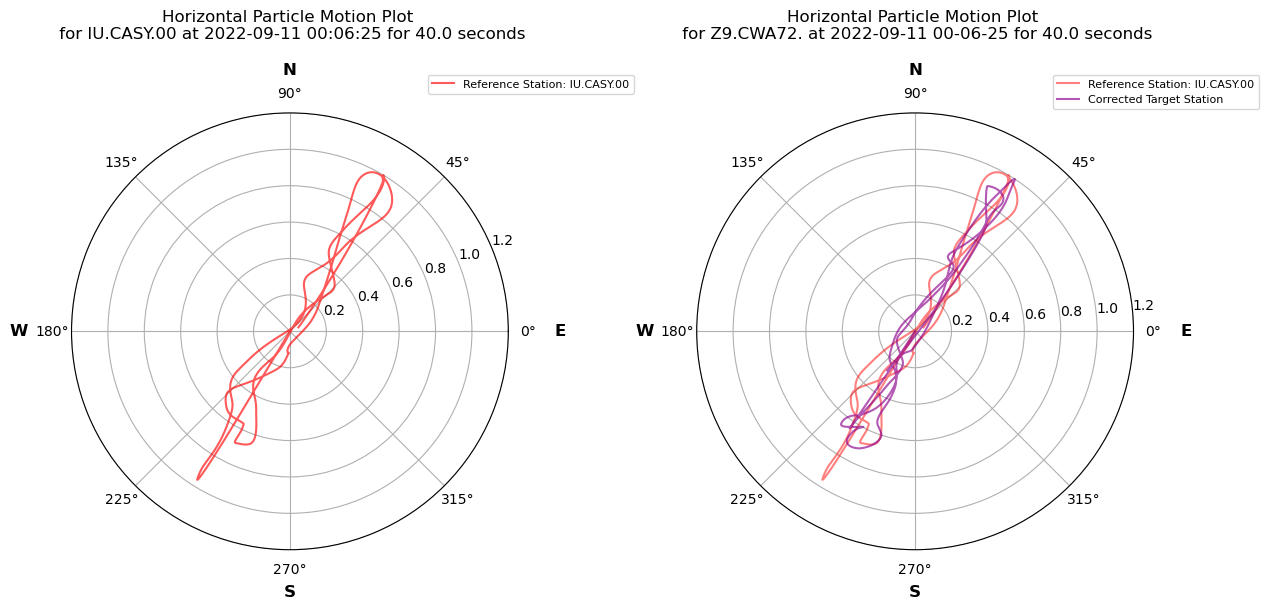

In [15]:
align.cc_correction(ref_dict, 
                    target_dict, 
                    NS_channel, 
                    EW_channel, 
                    col_n = 4, 
                    underlying_plot='reference', 
                    png_title='Example_Reference_CC',
                    save_png=True)

## 6. Tabulating Orientation

A similar process can be done through tabulate_cc_correction. The same cross correlation is applied to the waveforms, only now it tabulates the orientations instead of plotting them.

ref_dict is a reference dictionary.

target_dict is a target dictionary.

NS_channel is the north-south sensor channels.

EW_channel is the east-west sensor channels.

location is the file and table title (default = 'default_title).

In [16]:
ref_dict = CASY_filt
target_dict = CWA_filt
NS_channel = ['BH1', 'HHN']
EW_channel = ['BH2', 'HHE']

In [17]:
align.tabulate_cc_correction(ref_dict,
                             target_dict,
                             NS_channel,
                             EW_channel,
                             location = 'Tutorial_Example_PNG')

Processing reference station: IU.CASY.00...
Processing Z9.CWA72....
Alignments for Tutorial_Example_PNG Earthquake @ 2022-09-11 00-06-25 (UTC):


,Station,Angle Correction
0,Z9.CWA72.,35.20


## 7. WIP Store Aligned Streams

rotate_stream() is a work in progress. Angles obtained by the cross correlation process in parts 5 and 6 can be entered to manually rotate the waveform and gain a dictionary output of the aligned NS and EW values for the waveform.


wave_dict is a dictionary

NS_channel is the north-south sensor channels.

EW_channel is the east-west sensor channels.

angle_list is in degrees



In [44]:
wave_dict = CWA_filt
NS_channel = ["HHN"]
EW_channel = ["HHE"]
angle_list = [35.20] # Value gained from CC correction

In [24]:
align.rotate_stream(wave_dict, 
                    NS_channel, 
                    EW_channel, 
                    angle_list)

Processing Z9.CWA72....


{'Z9.CWA72.': array([[ 0.00000000e+00, -2.22883563e-07, -2.38367397e-06, ...,
         -1.50343874e-01, -1.52150143e-01, -1.53676088e-01],
        [ 0.00000000e+00, -3.57411777e-07, -3.82014250e-06, ...,
         -2.10872416e-01, -2.12958948e-01, -2.14713467e-01]],
       shape=(2, 4001))}

For plotting

Processing Z9.CWA72....


Text(0.5, 0, 'Time (s)$\\times10^{-2}$')

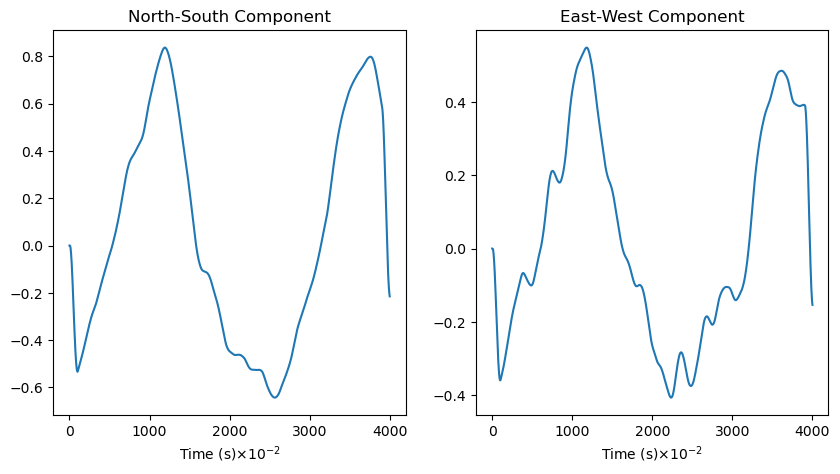

In [42]:
aligned = align.rotate_stream(wave_dict, 
                    NS_channel, 
                    EW_channel, 
                    angle_list)

fig, ax = plt.subplots(1,2, figsize=(10,5))
ax[0].plot(aligned['Z9.CWA72.'][1])
ax[0].set_title('North-South Component')
ax[0].set_xlabel(r'Time (s)$\times10^{-2}$')
ax[1].plot(aligned['Z9.CWA72.'][0])
ax[1].set_title('East-West Component')
ax[1].set_xlabel(r'Time (s)$\times10^{-2}$')


Compare to original NS, EW channels

Plotting Z9.CWA72.


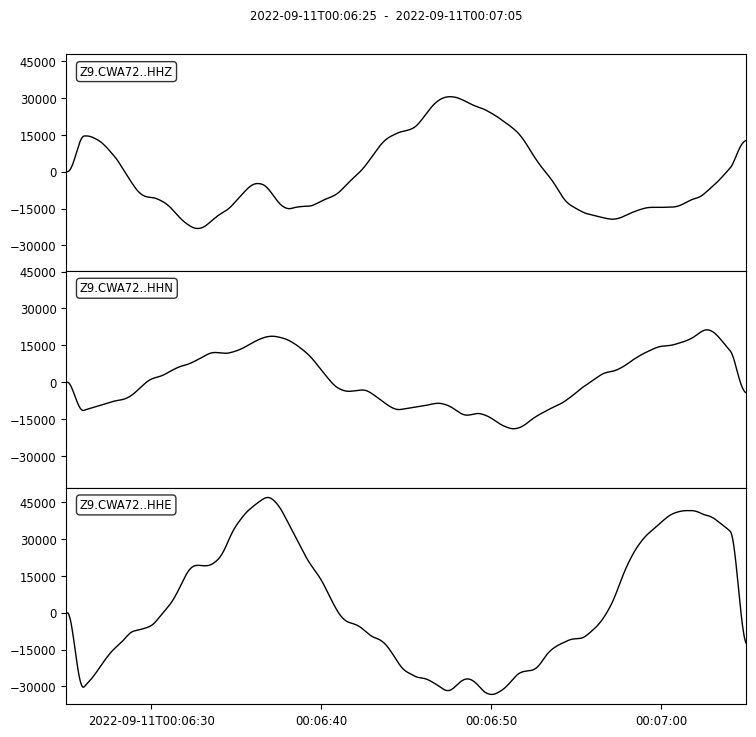

In [43]:
align.plot_streams(CWA_filt)